# Memorization Label Prediction and Independent Variables Effect Analysis

## Setup

### Environment Setup

In [1]:
# import sys
# import subprocess

# # packages = open("requirements.txt").read().splitlines()
# packages = open("requirements2.txt").read().splitlines()
# print(f"🔄 Synchronizing environment dependencies: {packages}...")
# subprocess.check_call([sys.executable, "-m", "pip", "install", "--upgrade"] + packages)
# print("✅ Synchronization complete. Packages are now compatible.")

In [111]:
from openai import OpenAI
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.metrics.pairwise import cosine_distances
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, f1_score, confusion_matrix, auc, RocCurveDisplay, roc_curve
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
import shap
from xgboost import XGBClassifier, XGBRegressor
from pulearn import ElkanotoPuClassifier
from sklearn.cluster import KMeans
from scipy.stats import multivariate_normal
from mpl_toolkits.mplot3d import Axes3D
import uuid
import json
from pathlib import Path
from utils import BASE_DIR, INPUT_DIR, PROMPTS_DIR, OUTPUTS_DIR, API_INPUT_DIR, API_OUTPUT_DIR, API_JOBS_DIR, create_prompt, create_batch_input_file, \
    send_input_to_api, wait_for_batch_completion, retrieve_api_output, output_jsonl_to_dataframe, run_whole_batch_process

API_KEY = os.getenv("OPENAI_API_KEY_UNIVERSITY")
client = OpenAI(api_key=API_KEY)

### Helper Functions

In [101]:
def expand_labels_to_one_hot_internal(df, task_type_schema, subject_schema):
    """
    Expands task types into primary/secondary one-hots, and subjects into 
    Level 2 (Primary Subject) and Level 3 (Secondary Subject) one-hots.
    """
    
    # 1. Prepare Task Type Columns
    task_ids = [label['id'] for label in task_type_schema['labels']]
    
    # 2. Prepare Subject Hierarchies
    # Map Level 3 (tag) -> Level 2 (category)
    tag_to_primary_map = {}
    all_level2_subjects = []
    all_level3_subjects = []
    
    for domain, categories in subject_schema.items():
        for category_name, tags in categories.items():
            all_level2_subjects.append(category_name)
            for tag in tags:
                tag_to_primary_map[tag] = category_name
                all_level3_subjects.append(tag)

    # Initialize columns with 0
    for tid in task_ids:
        df[f'task_primary_{tid}'] = 0
        df[f'task_secondary_{tid}'] = 0
        
    for l2 in set(all_level2_subjects):
        df[f'sub_primary_{l2}'] = 0
        
    for l3 in set(all_level3_subjects):
        df[f'sub_secondary_{l3}'] = 0

    # 3. Process Rows
    for idx, row in df.iterrows():
        # --- Task Types ---
        tt = row['task_type_labels']
        if isinstance(tt, str): tt = json.loads(tt)
        
        if tt.get('primary_task_type'):
            df.at[idx, f"task_primary_{tt['primary_task_type']}"] = 1
        for sec in tt.get('secondary_task_types', []):
            df.at[idx, f"task_secondary_{sec}"] = 1
            
        # --- Subjects ---
        st = row['subject_labels']
        if isinstance(st, str): st = json.loads(st)
        
        for tag in st.get('subject_tags', []):
            # Mark the Level 3 (Secondary) column
            df.at[idx, f"sub_secondary_{tag}"] = 1
            
            # Mark the corresponding Level 2 (Primary) column
            primary_cat = tag_to_primary_map.get(tag)
            if primary_cat:
                df.at[idx, f"sub_primary_{primary_cat}"] = 1
                
    return df

def extract_labels_to_one_hot(df):
    with open(INPUT_DIR / 'task_type_labels.json') as f: tt_schema = json.load(f)
    with open(INPUT_DIR / 'subject_labels.json') as f: sub_schema = json.load(f)
    df = expand_labels_to_one_hot_internal(df.copy(), tt_schema, sub_schema)
    return df

### Read and Process Dataframe

In [98]:
df_path = INPUT_DIR / "combined_questions_with_classification.xlsx"
df = pd.read_excel(df_path)
print("✅ Data loaded successfully.")

dist_ratio_threshold = 0.33
df['filter_out_by_threshold'] = df.apply(lambda row: row['dist_ratio'] > dist_ratio_threshold and row['likely_memorized_classification'] == 1, axis=1)
print(f"🔍 Applied distance ratio threshold of {dist_ratio_threshold}.")
print("DataFrame shape: ", df.shape)

✅ Data loaded successfully.
🔍 Applied distance ratio threshold of 0.33.
DataFrame shape:  (342, 29)


#### Filter Dataset

In [103]:
pred_df = df[~df['filter_out_by_threshold']].copy()
pred_df = pred_df[pred_df['dataset'] == 'exams_df']
print("DataFrame after filtering shape: ", pred_df.shape)

# for i in range(3):
#     # extract a random row['task_type_labels'] and row['subject_labels']
#     random_row = pred_df.sample(n=1)
#     print(f"Random row task_type_labels: {random_row['task_type_labels'].iloc[0]}")
#     print(f"Random row subject_labels: {random_row['subject_labels'].iloc[0]}")

DataFrame after filtering shape:  (208, 29)


#### Extract Task-Type, Subject Tags

In [104]:
pred_df = extract_labels_to_one_hot(pred_df)

In [105]:
print("Final Prediction DataFrame shape:", pred_df.shape)
print("Final Prediction DataFrame columns:")
# print columns nicely - after every 7 columns, print a new line
columns = pred_df.columns.tolist()
for i, col in enumerate(columns):
    if i % 7 == 0 and i > 0:
        print()  # newline
    print('\'' + col + '\'', end=", ")

Final Prediction DataFrame shape: (208, 124)
Final Prediction DataFrame columns:
'custom_id', 'id', 'dataset', 'source', 'likely_memorized_classification', 'avg_answer_distance', 'grade_std', 
'grade_mean', 'reasoning_tokens_std', 'reasoning_tokens_mean', 'dist_ratio', 'year', 'semester', 'moed', 
'question', 'section', 'points', 'question_hebrew', 'solution_hebrew', 'avg_score', 'std_score', 
'max_score', 'avg_score_norm', 'std_score_norm', 'question_english', 'solution_english', 'subject_labels', 'task_type_labels', 
'filter_out_by_threshold', 'task_primary_DS_DESIGN', 'task_secondary_DS_DESIGN', 'task_primary_ALG_DESIGN', 'task_secondary_ALG_DESIGN', 'task_primary_PROOF_CORRECTNESS', 'task_secondary_PROOF_CORRECTNESS', 
'task_primary_COMPLEXITY_ANALYSIS', 'task_secondary_COMPLEXITY_ANALYSIS', 'task_primary_AMORTIZED_ANALYSIS', 'task_secondary_AMORTIZED_ANALYSIS', 'task_primary_RECURRENCE_SOLVE', 'task_secondary_RECURRENCE_SOLVE', 'task_primary_ASYMPTOTIC_LAWS', 
'task_secondary_ASYM

## Label Prediction

### Configuration

In [68]:
# # 1. Define Column Groups
# numeric_cols = ['avg_score_norm', 'std_score_norm']
# target_column = 'likely_memorized_classification'

# # 2. Define the 4 Model Variations
# # Each tuple represents: (Task Type Level, Subject Level)
# model_configs = {
#     "Model_1_Primary_Task_Primary_Sub": ('task_primary_', 'sub_primary_'),
#     "Model_2_Primary_Task_Secondary_Sub": ('task_primary_', 'sub_secondary_'),
#     "Model_3_Secondary_Task_Primary_Sub": ('task_secondary_', 'sub_primary_'),
#     "Model_4_Secondary_Task_Secondary_Sub": ('task_secondary_', 'sub_secondary_')
# }

# model_results = {}

# Configuration
target_col = 'likely_memorized_classification'
numeric_cols = ['avg_score_norm', 'std_score_norm']
hierarchies = {
    "TaskPri_SubPri": ('task_primary_', 'sub_primary_'),
    "TaskPri_SubSec": ('task_primary_', 'sub_secondary_'),
    "TaskSec_SubPri": ('task_secondary_', 'sub_primary_'),
    "TaskSec_SubSec": ('task_secondary_', 'sub_secondary_')
}

all_results = []

In [113]:
# print null values in pred_df, where null > 0
print("Null values in final DataFrame:")
null_counts = pred_df[numeric_cols + [target_col] + [col for col in pred_df.columns if col.startswith('task_') or col.startswith('sub_')]].isnull().sum()
null_counts = null_counts[null_counts > 0]
print(null_counts)

# present value counts for sub_secondary_Big-Ω sub_secondary_Big-Θ (only these 2 columns)
print("\nValue counts for 'sub_secondary_Big-Ω':")
print(pred_df['sub_secondary_Big-Ω'].value_counts())
print("\nValue counts for 'sub_secondary_Big-Θ':")
print(pred_df['sub_secondary_Big-Θ'].value_counts())

# 1. Fix Binary/One-Hot Nulls
# Identify all one-hot columns to ensure they are complete
binary_cols = [col for col in pred_df.columns if col.startswith(('task_', 'sub_'))]
pred_df[binary_cols] = pred_df[binary_cols].fillna(0)

Null values in final DataFrame:
avg_score_norm         161
std_score_norm         161
sub_secondary_Big-Ω    199
sub_secondary_Big-Θ    196
dtype: int64

Value counts for 'sub_secondary_Big-Ω':
sub_secondary_Big-Ω
1.0    9
Name: count, dtype: int64

Value counts for 'sub_secondary_Big-Θ':
sub_secondary_Big-Θ
1.0    12
Name: count, dtype: int64


In [70]:
# print null values in pred_df, where null > 0 after correction
print("Updated null values in final DataFrame:")
null_counts = pred_df[numeric_cols + [target_col] + [col for col in pred_df.columns if col.startswith('task_') or col.startswith('sub_')]].isnull().sum()
null_counts = null_counts[null_counts > 0]
print(null_counts)

Updated null values in final DataFrame:
avg_score_norm    161
std_score_norm    161
dtype: int64


### Possible Logistic Reression Models
Including different combinations of primary and secondary labels from task types, subjects. 
Applying Lasso (L1) regression and KFold cross validation to avoid overfitting.

In [94]:
# Ensure full table display
pd.set_option('display.max_columns', None)
pd.set_option('display.expand_frame_repr', False)

all_results = []

for h_name, (task_pre, sub_pre) in hierarchies.items():
    selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))]
    
    variations = [
        {"name": f"{h_name}_AllData_NoScores", "df": pred_df, "cols": selected_one_hot},
        {"name": f"{h_name}_Subset_WithScores", "df": pred_df.dropna(subset=numeric_cols), "cols": selected_one_hot + numeric_cols}
    ]

    for var in variations:
        X = var['df'][var['cols']]
        y = var['df'][target_col]
        
        if len(X) < 10: continue 

        pipeline = Pipeline([
            ('interactions', PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)),
            ('scaler', StandardScaler()),
            ('clf', LogisticRegressionCV(
                cv=StratifiedKFold(min(5, len(np.unique(y)))), 
                penalty='l1', 
                solver='liblinear', 
                scoring='roc_auc',
                max_iter=5000,
                random_state=42
            ))
        ])

        try:
            pipeline.fit(X, y)
            best_clf = pipeline.named_steps['clf']
            
            # 1. Get CV AUC Score (mean of the max scores across C values)
            auc_cv = np.mean(np.max(best_clf.scores_[1], axis=1))
            
            # 2. Get predictions to calculate other metrics correctly
            y_pred = pipeline.predict(X)
            
            acc = accuracy_score(y, y_pred)
            f1 = f1_score(y, y_pred) # Correct F1 calculation
            active_feats = (best_clf.coef_ != 0).sum()
            true_positive_rate = ((y == 1) & (y_pred == 1)).sum() / (y == 1).sum() if (y == 1).sum() > 0 else np.nan

            tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()
            fnr = fn / (tp + fn) if (tp + fn) > 0 else 0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            
            
        except Exception as e:
            print(f"Error in {var['name']}: {e}")
            auc_cv, acc, f1, fnr, fpr, active_feats = np.nan, np.nan, np.nan, np.nan, np.nan, 0

        all_results.append({
            "Model_Name": var['name'],
            "Sample_Size": len(X),
            "Features_In": len(var['cols']),
            "Active_After_Lasso": active_feats,
            "CV_ROC_AUC": auc_cv,
            "Accuracy": acc,
            "F1_Score": f1,
            "False_Negative_Rate": fnr,
            "False_Positive_Rate": fpr
        })

results_df = pd.DataFrame(all_results)
display(results_df.sort_values(by="CV_ROC_AUC", ascending=False))

,Model_Name,Sample_Size,Features_In,Active_After_Lasso,CV_ROC_AUC,Accuracy,F1_Score,False_Negative_Rate,False_Positive_Rate
2,TaskPri_SubSec_AllData_NoScores,208,66,116,0.727316,0.927885,0.941634,0.047244,0.111111
0,TaskPri_SubPri_AllData_NoScores,208,29,75,0.692646,0.841346,0.872587,0.110236,0.234568
1,TaskPri_SubPri_Subset_WithScores,47,31,79,0.656162,1.000000,1.000000,0.000000,0.000000
6,TaskSec_SubSec_AllData_NoScores,208,66,175,0.646716,0.927885,0.938272,0.102362,0.024691
3,TaskPri_SubSec_Subset_WithScores,47,68,43,0.620798,0.978723,0.985507,0.000000,0.076923
7,TaskSec_SubSec_Subset_WithScores,47,68,60,0.620098,0.978723,0.985507,0.000000,0.076923
4,TaskSec_SubPri_AllData_NoScores,208,29,100,0.618667,0.850962,0.877470,0.125984,0.185185
5,TaskSec_SubPri_Subset_WithScores,47,31,84,0.568627,1.000000,1.000000,0.000000,0.000000


It seems TaskPri_SubSec_AllData_NoScores model acheived the best results. Let's examine the coefficients:

In [73]:
SELECTED_MODEL = "TaskPri_SubSec_AllData_NoScores"
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

# 1. Isolate the specific configuration
# selected hierarchy is SELECTED_MODEL until the second underscore (not including) - as substring, e.g. TaskPri_SubPri from TaskPri_SubPri_Subset_WithScores
selected_hierarchy = SELECTED_MODEL.split('_Subset')[0].split('_AllData')[0]
task_pre, sub_pre = hierarchies[selected_hierarchy]
selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))]
if "WithScores" in SELECTED_MODEL:
    df_in_use = pred_df.dropna(subset=numeric_cols)
    selected_one_hot += numeric_cols

X_model = df_in_use[selected_one_hot]
y_model = df_in_use[target_col]

# 2. Re-fit or access your existing pipeline for this specific model
# (Assuming 'pipeline' is the one fitted for TaskPri_SubSec_AllData_NoScores)
pipeline.fit(X_model, y_model)

# 3. Extract components
intercept = pipeline.named_steps['clf'].intercept_[0]
coefficients = pipeline.named_steps['clf'].coef_[0]
feature_names = pipeline.named_steps['interactions'].get_feature_names_out(selected_one_hot)

# 4. Filter for non-zero (active) features
active_indices = np.where(coefficients != 0)[0]
active_coeffs = coefficients[active_indices]
active_names = feature_names[active_indices]

# 5. Format the formula
formula_parts = [f"{intercept:.4f}"]
for coeff, name in zip(active_coeffs, active_names):
    sign = "+" if coeff >= 0 else "-"
    formula_parts.append(f" {sign} ({abs(coeff):.4f} * {name})")

full_formula = "".join(formula_parts)

print(f"--- Log-Odds Formula for {target_col} ---")
print(f"logit(p) = {full_formula}")

# Create a DataFrame for easier inspection
formula_df = pd.DataFrame({
    'Feature': active_names,
    'Coefficient': active_coeffs
}).sort_values(by='Coefficient', key=abs, ascending=False)

display(formula_df)

--- Log-Odds Formula for likely_memorized_classification ---
logit(p) = 4.0875 + (0.7886 * task_primary_DS_DESIGN) + (0.4010 * task_primary_ALG_DESIGN) + (0.6516 * task_primary_PROOF_CORRECTNESS) - (0.2259 * task_primary_COMPLEXITY_ANALYSIS) + (0.4461 * task_primary_COUNTEREXAMPLE) + (0.1648 * task_primary_AUGMENT_DS) - (0.3690 * task_primary_MCQ_TF) - (0.0541 * sub_secondary_Divide-and-Conquer) - (0.3358 * sub_secondary_Big-O) + (0.6992 * sub_secondary_lower-o-notation) - (0.6182 * sub_secondary_Accounting Method) + (0.0421 * sub_secondary_Non-Comparison Sorting) - (0.5378 * sub_secondary_Sentinel Nodes) + (0.3563 * sub_secondary_Arrays) - (0.0707 * sub_secondary_Recursive Definitions) + (0.1920 * sub_secondary_Delete) + (0.2212 * sub_secondary_Priority Queues) + (0.0502 * sub_secondary_Chaining) + (0.7632 * sub_secondary_Hash Tables) + (0.0501 * sub_secondary_Insert) - (0.3639 * sub_secondary_Recurrence Relations) + (0.3486 * task_primary_DS_DESIGN sub_secondary_Big-O) - (0.1271 * ta

,Feature,Coefficient
51,task_primary_MCQ_TF sub_secondary_Logarithms,-2.746218
52,task_primary_MCQ_TF sub_secondary_Binary Heaps,-2.744187
28,task_primary_ALG_DESIGN sub_secondary_Divide-and-Conquer,-1.665224
32,task_primary_ALG_DESIGN sub_secondary_Selection Problem,-1.435155
59,sub_secondary_Order-Statistic Trees sub_secondary_Big-Θ,-1.366642
62,sub_secondary_Big-O sub_secondary_Upper/Lower Bounds,-1.054302
50,task_primary_MCQ_TF sub_secondary_Search,-1.027877
91,sub_secondary_AVL Trees sub_secondary_Big-Θ,-1.027236
54,task_primary_MCQ_TF sub_secondary_Binomial Heaps,0.950060
68,sub_secondary_Big-O sub_secondary_Big-Ω,-0.927943


C:\Users\liaso\AppData\Local\Temp\ipykernel_41176\1057215390.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='Total_Effect', y='Feature', palette=colors)


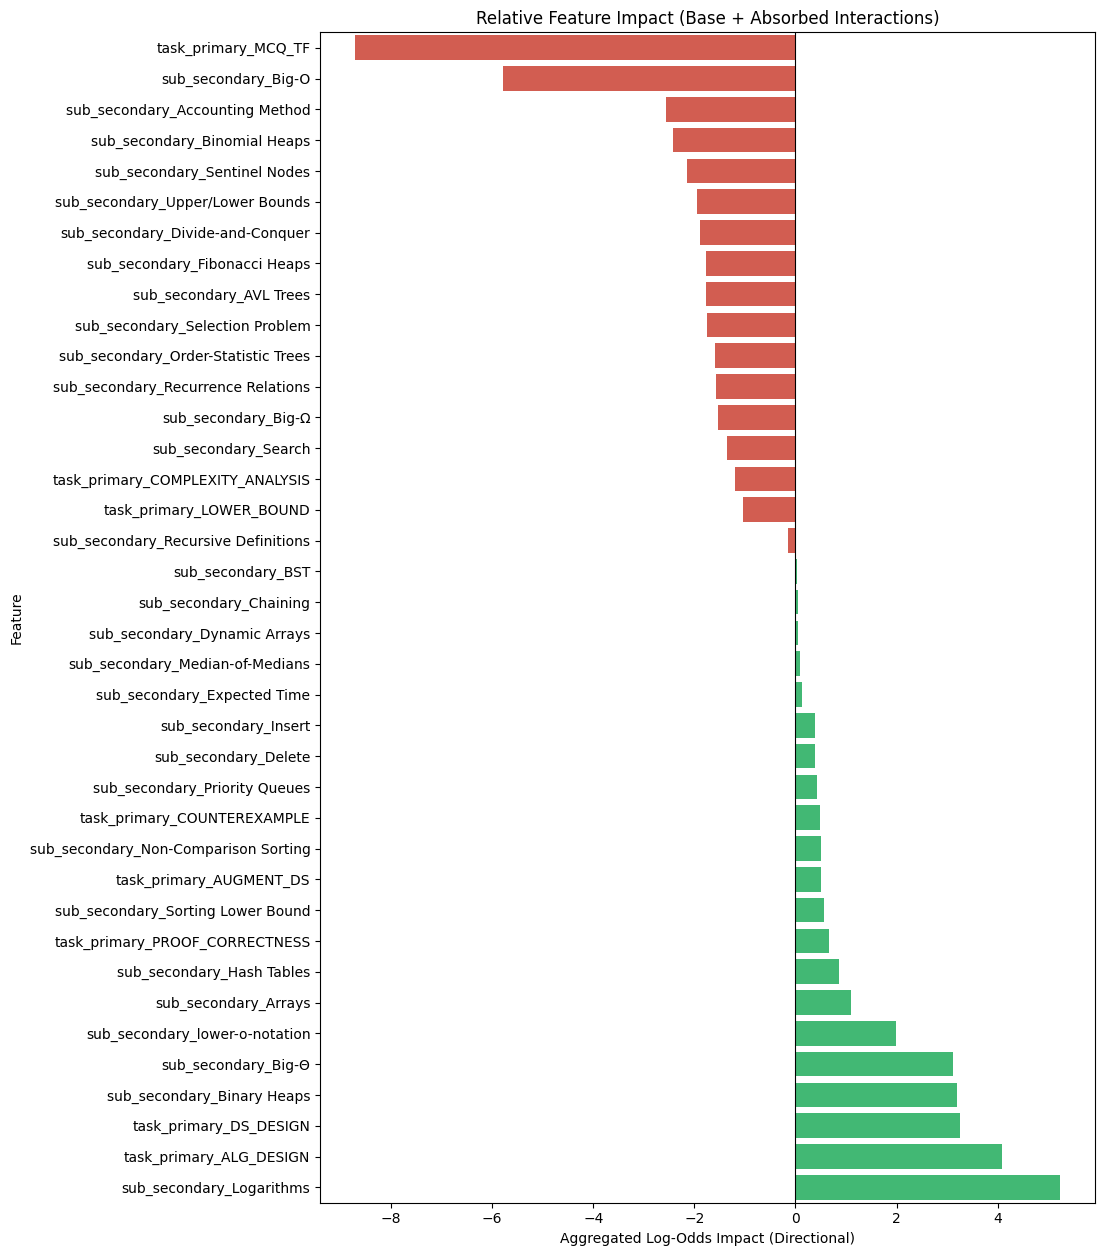

In [ ]:
def plot_feature_importance_with_interactions(pipeline, base_features):
    # 1. Extract coefficients and names
    coefs = pipeline.named_steps['clf'].coef_[0]
    all_names = pipeline.named_steps['interactions'].get_feature_names_out(base_features)
    
    # 2. Map magnitudes to base features
    feature_effects = {feat: {'magnitude': 0, 'direction': 0} for feat in base_features}
    
    for coef, name in zip(coefs, all_names):
        if coef == 0: continue
        
        # Check which base features are part of this (base or interaction)
        for base in base_features:
            if base in name:
                feature_effects[base]['magnitude'] += abs(coef)
                # Direction is dictated by the base feature's own sign if available, 
                # or the sign of the interaction
                if base == name:
                    feature_effects[base]['direction'] = np.sign(coef)
                elif feature_effects[base]['direction'] == 0:
                    feature_effects[base]['direction'] = np.sign(coef)

    # 3. Convert to DataFrame for plotting
    plot_df = pd.DataFrame([
        {'Feature': k, 'Total_Effect': v['magnitude'] * v['direction'], 'Abs_Magnitude': v['magnitude']}
        for k, v in feature_effects.items() if v['magnitude'] > 0
    ]).sort_values(by='Total_Effect')

    # 4. Create Plot
    plt.figure(figsize=(10, len(plot_df) * 0.4))
    colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in plot_df['Total_Effect']]
    
    sns.barplot(data=plot_df, x='Total_Effect', y='Feature', palette=colors)
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Relative Feature Impact (Base + Absorbed Interactions)')
    plt.xlabel('Aggregated Log-Odds Impact (Directional)')
    plt.show()

# Usage
plot_feature_importance_with_interactions(pipeline, selected_one_hot)

C:\Users\liaso\AppData\Local\Temp\ipykernel_41176\3114616488.py:50: UserWarning: The palette list has more values (30) than needed (2), which may not be intended.
  ax = sns.barplot(


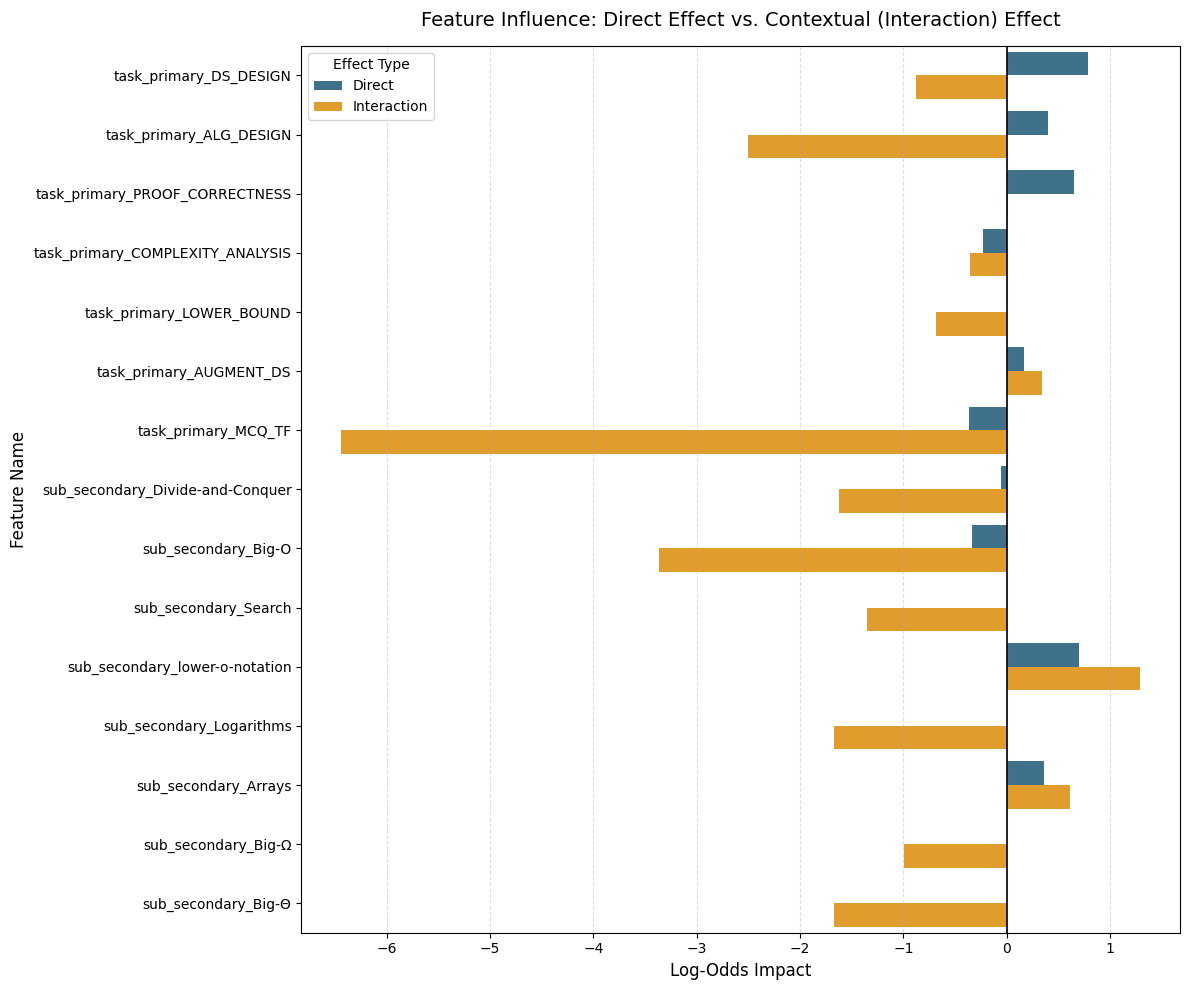

In [80]:
def plot_direct_vs_interaction_relation(pipeline, base_features, top_n=15):
    """
    Creates a grouped bar chart comparing direct vs interaction effects,
    colored by direct / indirect effect
    """
    # 1. Extract coefficients and names from the pipeline
    coefs = pipeline.named_steps['clf'].coef_[0]
    all_names = pipeline.named_steps['interactions'].get_feature_names_out(base_features)
    
    # 2. Map effects to base features
    # Tracking Direct and Interaction sums separately
    effect_tracker = {feat: {'Direct': 0.0, 'Interaction': 0.0} for feat in base_features}
    
    for coef, name in zip(coefs, all_names):
        if coef == 0: continue
        
        parts = name.split(' ') # Interactions are separated by spaces in get_feature_names_out
        
        if len(parts) == 1:
            # Direct effect of the base feature
            if parts[0] in effect_tracker:
                effect_tracker[parts[0]]['Direct'] = coef
        else:
            # Interaction effect - attribute to all constituent features
            for p in parts:
                if p in effect_tracker:
                    effect_tracker[p]['Interaction'] += coef

    # 3. Prepare DataFrame for plotting
    plot_data = []
    for feat, effects in effect_tracker.items():
        total_abs_magnitude = abs(effects['Direct']) + abs(effects['Interaction'])
        if total_abs_magnitude > 0:
            plot_data.append({'Feature': feat, 'Type': 'Direct', 'Value': effects['Direct'], 'Total': total_abs_magnitude})
            plot_data.append({'Feature': feat, 'Type': 'Interaction', 'Value': effects['Interaction'], 'Total': total_abs_magnitude})
            
    df_plot = pd.DataFrame(plot_data)
    
    # Filter for top N most dominant features
    top_feats = df_plot.sort_values('Total', ascending=False)['Feature'].unique()[:top_n]
    df_plot = df_plot[df_plot['Feature'].isin(top_feats)]

    # 4. Generate the Visualization
    plt.figure(figsize=(12, 10))
    
    # Create the directional color palette: Green for positive values, Red for negative
    custom_palette = ["#337796" if val >= 0 else "#ffa310" for val in df_plot['Value']]
    
    # Use dodge=True for grouped bars and pass the custom color list to palette
    ax = sns.barplot(
        data=df_plot, 
        y='Feature', 
        x='Value', 
        hue='Type', 
        palette=custom_palette,
        dodge=True
    )
    
    # Aesthetic adjustments
    plt.axvline(0, color='black', linewidth=1.2)
    plt.title('Feature Influence: Direct Effect vs. Contextual (Interaction) Effect', fontsize=14, pad=15)
    plt.xlabel('Log-Odds Impact', fontsize=12)
    plt.ylabel('Feature Name', fontsize=12)
    
    # Clean up legend (remove duplicate color labels if necessary)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='Effect Type', loc='best')
    
    plt.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

# Usage
plot_direct_vs_interaction_relation(pipeline, selected_one_hot, top_n=15)

### XGBoost Classifier

#### Hyperparameter Search

In [ ]:
# 1. Prepare Data for TaskPri_SubSec
task_pre, sub_pre = "task_primary_", "sub_secondary_"
selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))]

X = pred_df[selected_one_hot]
y = pred_df['likely_memorized_classification']

# 1. Define the Pipeline
# We keep interaction_only=True to focus on relationships between different labels
pipeline = Pipeline([
    ('interactions', PolynomialFeatures(interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# 2. Define the Grid
# We include 'degree' here to see if triplets (Degree 3) add value or just overfit
param_grid = {
    'interactions__degree': [1, 2, 3],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [2, 3, 4],
    'clf__n_estimators': [50, 100]
}

# 3. Execute Exhaustive Search
# StratifiedKFold is essential here to maintain label balance in the 208 rows
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=StratifiedKFold(5), 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X, y)

print(f"Best Degree: {grid_search.best_params_['interactions__degree']}")
print(f"Best Learning Rate: {grid_search.best_params_['clf__learning_rate']}")
print(f"Best Max Depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best N Estimators: {grid_search.best_params_['clf__n_estimators']}")
print(f"Best AUC: {grid_search.best_score_:.4f}")

Best Degree: 1
Best Learning Rate: 0.05
Best Max Depth: 2
Best N Estimators: 50
Best AUC: 0.7549


c:\projects\LLMsForEducation\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [18:34:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Plotting Best Model Results

In [84]:
# Define the best parameters
best_params = {
    'learning_rate': 0.05,
    'max_depth': 2,
    'n_estimators': 50,
    'use_label_encoder': False,
    'eval_metric': 'logloss',
    'random_state': 42
}

# Build the pipeline with Degree 1 (no interactions)
best_model_pipeline = Pipeline([
    ('interactions', PolynomialFeatures(degree=1, interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(**best_params))
])

best_model_pipeline.fit(X, y)

c:\projects\LLMsForEducation\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [13:50:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Pipeline(steps=[('interactions',
                 PolynomialFeatures(degree=1, include_bias=False,
                                    interaction_only=True)),
                ('scaler', StandardScaler()),
                ('clf',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               f...ts=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=50, n_jobs=None,
                               num_parallel_tree=None, ...))])

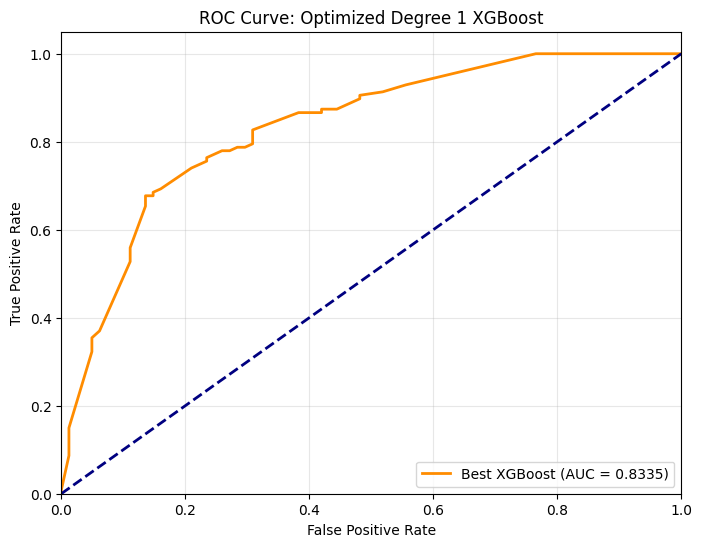

In [87]:
# Calculate probabilities
y_prob = best_model_pipeline.predict_proba(X)[:, 1]
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Best XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Optimized Degree 1 XGBoost')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

C:\Users\liaso\AppData\Local\Temp\ipykernel_41176\923100317.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')


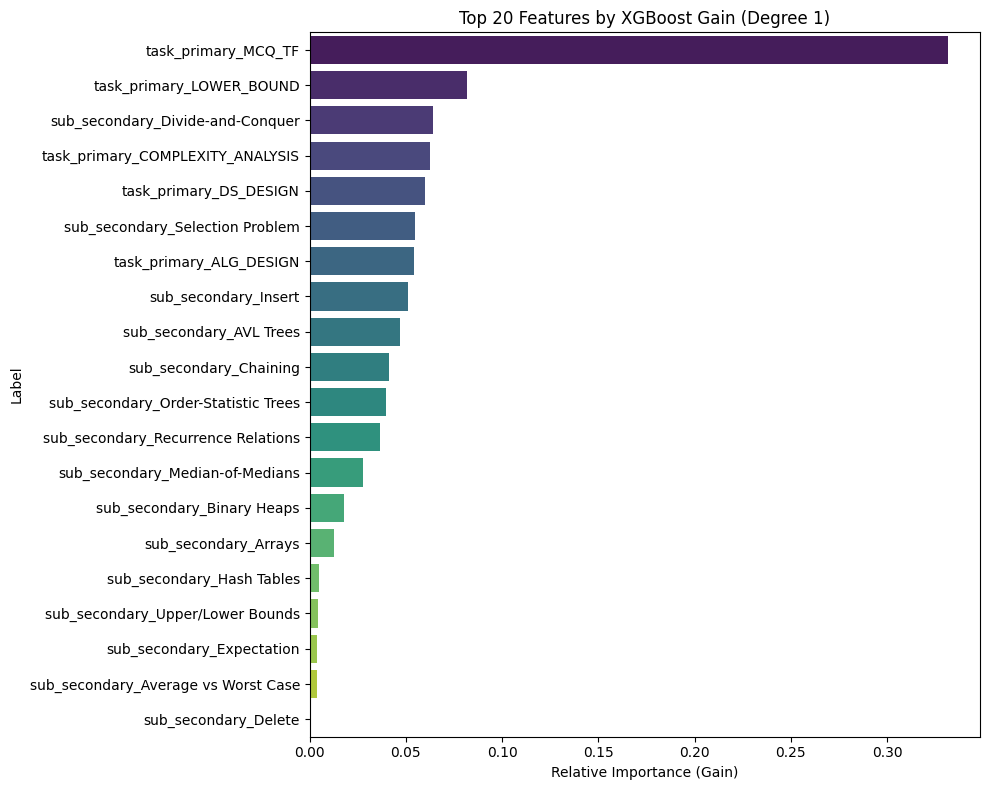

In [85]:
# Extract importances and names
importances = best_model_pipeline.named_steps['clf'].feature_importances_
feature_names = best_model_pipeline.named_steps['interactions'].get_feature_names_out(selected_one_hot)

# Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).head(20) # Top 20 features

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 20 Features by XGBoost Gain (Degree 1)')
plt.xlabel('Relative Importance (Gain)')
plt.ylabel('Label')
plt.tight_layout()
plt.show()

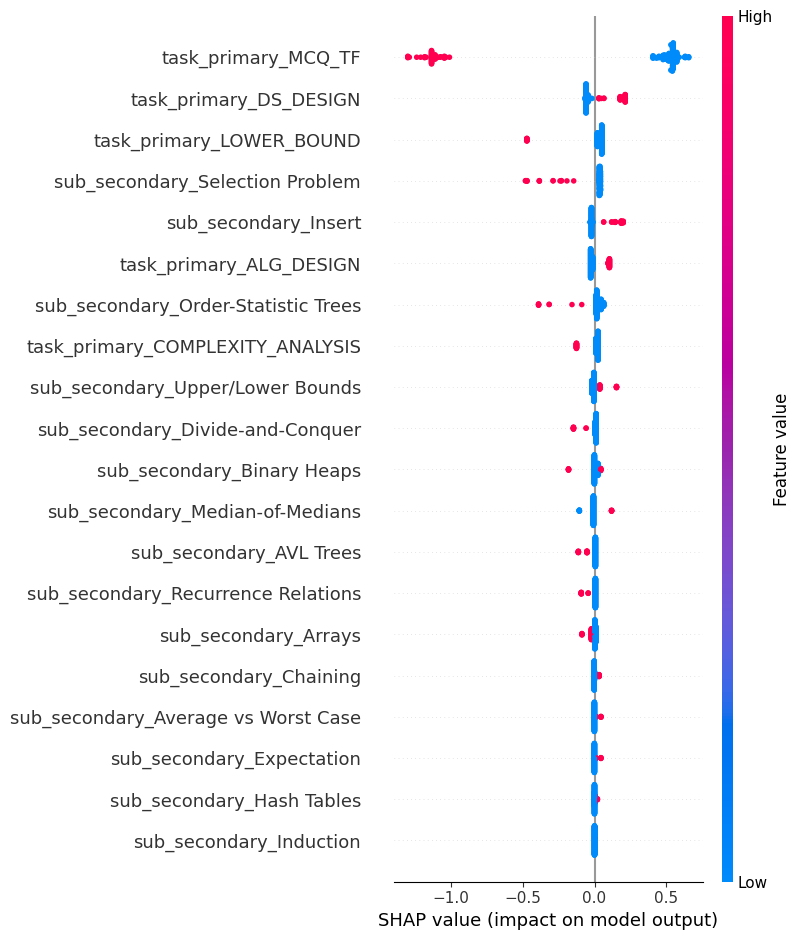

In [89]:
# 1. Transform the data through the pipeline's preprocessors
# Since Degree=1, this just scales the original features
X_transformed = best_model_pipeline.named_steps['scaler'].transform(
    best_model_pipeline.named_steps['interactions'].transform(X)
)

# 2. Calculate SHAP values for the XGBoost model
explainer = shap.TreeExplainer(best_model_pipeline.named_steps['clf'])
shap_values = explainer.shap_values(X_transformed)

# 3. Summary Plot: This shows magnitude AND direction
# Points to the right (positive) push toward 'Memorized' (1)
# Points to the left (negative) push toward 'Non-Memorized' (0)
shap.summary_plot(shap_values, X_transformed, feature_names=feature_names)

c:\projects\LLMsForEducation\.venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\projects\LLMsForEducation\.venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\liaso\AppData\Local\Temp\ipykernel_41176\331958973.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_20_signed, x='Signed_Impact', y='Feature', palette=colors)


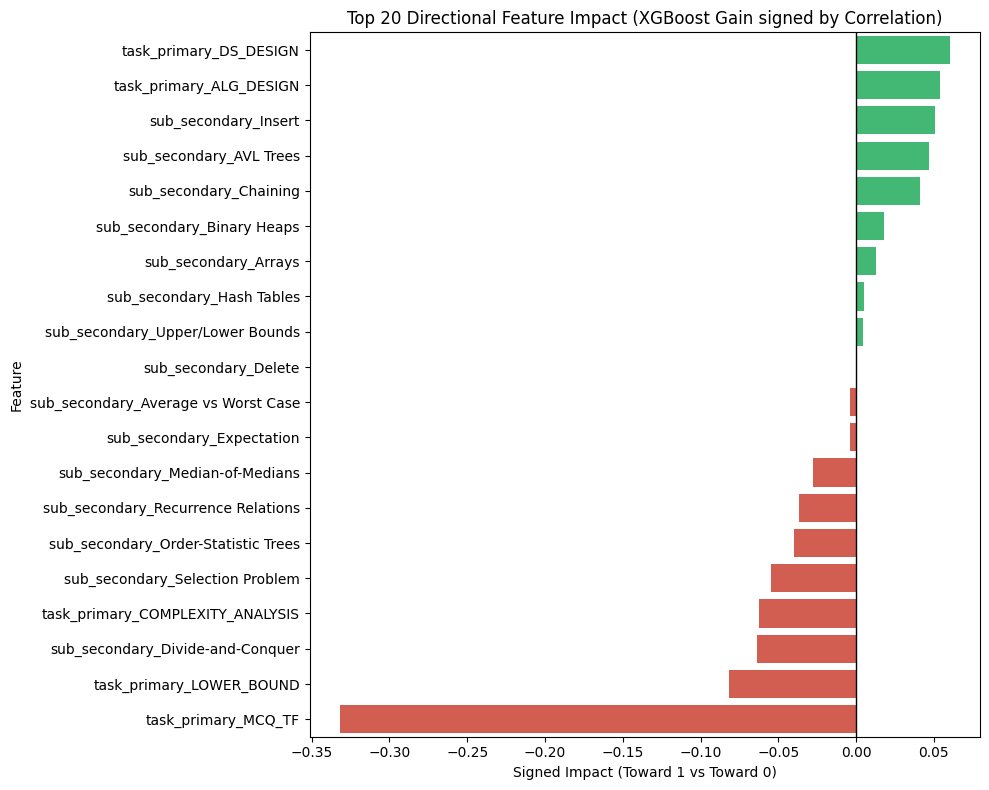

In [91]:
# 1. Calculate Correlation Direction
# We check if the feature is positively or negatively correlated with the target
correlations = X[selected_one_hot].corrwith(y)

# 2. Create Signed Importance DataFrame
signed_importance = pd.DataFrame({
    'Feature': feature_names,
    'Gain': importances,
    'Direction': [1 if correlations[f] > 0 else -1 for f in selected_one_hot]
})

signed_importance['Signed_Impact'] = signed_importance['Gain'] * signed_importance['Direction']

# 3. Filter for 20 most significant features
# We sort by the absolute magnitude (Gain) to find the 20 most powerful predictors
top_20_signed = signed_importance.sort_values(by='Gain', ascending=False).head(20)

# Re-sort the top 20 by the Signed_Impact for a clean diverging visual
top_20_signed = top_20_signed.sort_values(by='Signed_Impact', ascending=False)

# 4. Plot
plt.figure(figsize=(10, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in top_20_signed['Signed_Impact']]

sns.barplot(data=top_20_signed, x='Signed_Impact', y='Feature', palette=colors)
plt.axvline(0, color='black', linewidth=1)
plt.title('Top 20 Directional Feature Impact (XGBoost Gain signed by Correlation)')
plt.xlabel('Signed Impact (Toward 1 vs Toward 0)')
plt.tight_layout()
plt.show()

#### Checking if including grade stats helps performance - it doesn't...

In [97]:
# 1. Prepare Data for TaskPri_SubSec
task_pre, sub_pre = "task_primary_", "sub_secondary_"
selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))] + numeric_cols

X = pred_df[selected_one_hot]
y = pred_df['likely_memorized_classification']

# 1. Define the Pipeline
# We keep interaction_only=True to focus on relationships between different labels
pipeline = Pipeline([
    # ('interactions', PolynomialFeatures(interaction_only=True, include_bias=False)),
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42))
])

# 2. Define the Grid
# We include 'degree' here to see if triplets (Degree 3) add value or just overfit
param_grid = {
    # 'interactions__degree': [1, 2, 3],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [2, 3, 4],
    'clf__n_estimators': [50, 100]
}

# 3. Execute Exhaustive Search
# StratifiedKFold is essential here to maintain label balance in the 208 rows
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=StratifiedKFold(5), 
    scoring='roc_auc', 
    n_jobs=-1
)

grid_search.fit(X, y)

# print(f"Best Degree: {grid_search.best_params_['interactions__degree']}")
print(f"Best Learning Rate: {grid_search.best_params_['clf__learning_rate']}")
print(f"Best Max Depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best N Estimators: {grid_search.best_params_['clf__n_estimators']}")
print(f"Best AUC: {grid_search.best_score_:.4f}")

Best Learning Rate: 0.01
Best Max Depth: 2
Best N Estimators: 100
Best AUC: 0.7536


c:\projects\LLMsForEducation\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [14:51:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Cluster-Specific Analyses

### Unlikely Memorized Cluster

#### Correlation between LLM's and Students Grade STD, Mean 

### Likely Memorized Cluster

In [106]:
likely_memorized_pred_df = pred_df[pred_df['likely_memorized_classification'] == 1].copy()
print("DataFrame of likely memorized questions shape:", likely_memorized_pred_df.shape)

DataFrame of likely memorized questions shape: (127, 124)


#### LLM's Grade Mean Prediction

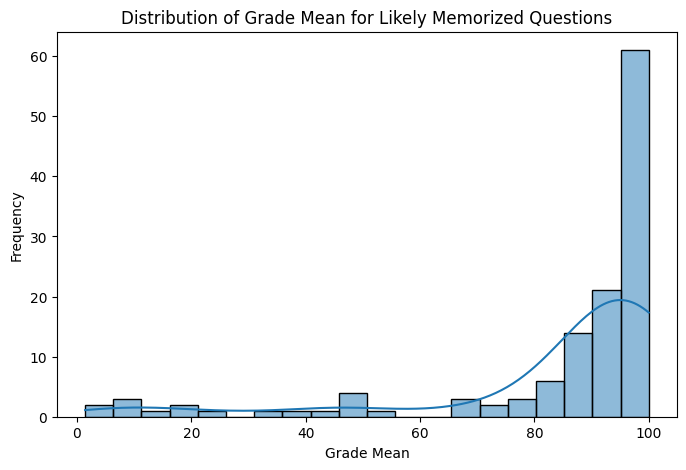

In [107]:
target_col = 'grade_mean'
# show distribution of grade_mean in likely_memorized_pred_df
plt.figure(figsize=(8, 5))
sns.histplot(likely_memorized_pred_df[target_col], bins=20, kde=True)
plt.title('Distribution of Grade Mean for Likely Memorized Questions')
plt.xlabel('Grade Mean')
plt.ylabel('Frequency')
plt.show()

##### Hyperparameter Search

In [ ]:
# 1. Prepare Data for TaskPri_SubSec
task_pre, sub_pre = "task_primary_", "sub_secondary_"
selected_one_hot = [c for c in pred_df.columns if c.startswith((task_pre, sub_pre))]

X = pred_df[selected_one_hot]
y = pred_df[target_col]

# 1. Define the Pipeline
# We keep interaction_only=True to focus on relationships between different labels
pipeline = Pipeline([
    ('interactions', PolynomialFeatures(interaction_only=True, include_bias=True)),
    ('scaler', StandardScaler()),
    ('clf', XGBRegressor(use_label_encoder=False, eval_metric='rmse', random_state=42))
])

# 2. Define the Grid
# We include 'degree' here to see if triplets (Degree 3) add value or just overfit
param_grid = {
    'interactions__degree': [1, 2, 3],
    'clf__learning_rate': [0.01, 0.05, 0.1],
    'clf__max_depth': [2, 3, 4],
    'clf__n_estimators': [50, 100]
}

# 3. Execute Exhaustive Search
# StratifiedKFold is essential here to maintain label balance in the 208 rows
grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=KFold(5, shuffle=True, random_state=42), 
    scoring='neg_mean_squared_error', 
    n_jobs=-1
)

grid_search.fit(X, y)

print(f"Best Degree: {grid_search.best_params_['interactions__degree']}")
print(f"Best Learning Rate: {grid_search.best_params_['clf__learning_rate']}")
print(f"Best Max Depth: {grid_search.best_params_['clf__max_depth']}")
print(f"Best N Estimators: {grid_search.best_params_['clf__n_estimators']}")
print(f"Best AUC: {grid_search.best_score_:.4f}")

ValueError: Supported target types are: ('binary', 'multiclass'). Got 'continuous' instead.